### 01. Introduction
freMTPL2freq dataset is a set of data on french motor insurance. 
We import this dataset into a dataframe for exploratory data analysis.
IDpol: The policy ID (used to link with the claims dataset).
ClaimNb: Number of claims during the exposure period.

- Exposure: The period of exposure for a policy, in years.
- VehPower: The power of the car (ordered values).
- VehAge: The vehicle age, in years.
- DrivAge: The driver age, in years (in France, people can drive a car at 18).
- BonusMalus: Bonus/malus, between 50 and 350: <100 means bonus, >100 means malus in France.
- VehBrand: The car brand (unknown categories).
- VehGas: The car gas, Diesel or regular.
- Area: The density value of the city community where the car driver lives in: from "A" for rural area to "F" for urban centre.
- Density: The density of inhabitants (number of inhabitants per square-kilometer) of the city where the car driver lives in.
- Region: The policy region in France (based on the 1970-2015 classification).

In [15]:
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
full_motor_data = fetch_openml(data_id=43593, as_frame=True, parser="auto")
df = full_motor_data.frame

df.head(5)

,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1,0.10,D,5,0,55,50,B12,Regular,1217,R82
1,1,0.77,D,5,0,55,50,B12,Regular,1217,R82
2,1,0.75,B,6,2,52,50,B12,Diesel,54,R22
3,1,0.09,B,7,0,46,50,B12,Diesel,76,R72
4,1,0.84,B,7,0,46,50,B12,Diesel,76,R72


### 02. Dataset overview

In [16]:
print("Shape:", df.shape)
print("\nTypes:\n",df.dtypes)
print("\nDescription:\n",df.describe().round(2))

Shape: (678013, 11)

Types:
 ClaimNb         int64
Exposure      float64
Area           object
VehPower        int64
VehAge          int64
DrivAge         int64
BonusMalus      int64
VehBrand       object
VehGas         object
Density         int64
Region         object
dtype: object

Description:
          ClaimNb   Exposure   VehPower     VehAge    DrivAge  BonusMalus  \
count  678013.00  678013.00  678013.00  678013.00  678013.00   678013.00   
mean        0.05       0.53       6.45       7.04      45.50       59.76   
std         0.24       0.36       2.05       5.67      14.14       15.64   
min         0.00       0.00       4.00       0.00      18.00       50.00   
25%         0.00       0.18       5.00       2.00      34.00       50.00   
50%         0.00       0.49       6.00       6.00      44.00       50.00   
75%         0.00       0.99       7.00      11.00      55.00       64.00   
max        16.00       2.01      15.00     100.00     100.00      230.00   

         Densit

### 03. ClaimNb analysis

We can see that the overwhelming majority of cases have no claims

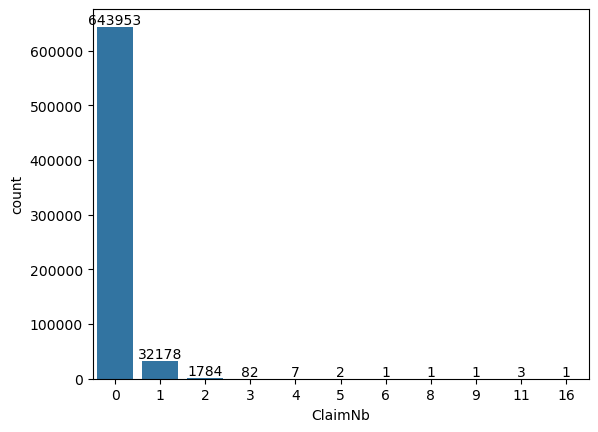

Proportion with claims: 5.02 %


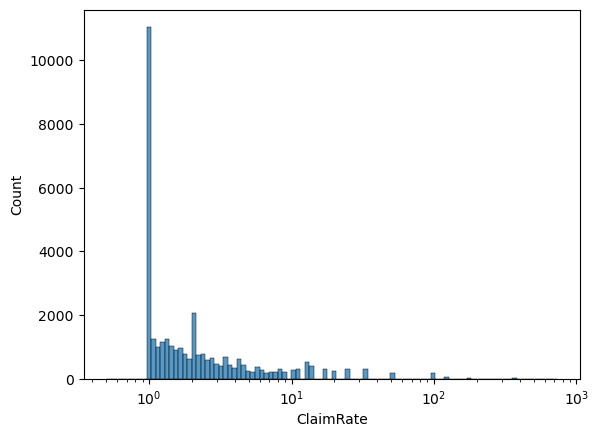

In [17]:
ax = sns.countplot(x="ClaimNb",data=df)
for bar in ax.containers:
    ax.bar_label(bar)

plt.show()

df["ClaimRate"] = df["ClaimNb"] / df["Exposure"]

sns.histplot(df["ClaimRate"], bins = 100,log_scale=True)

print(f"Proportion with claims: {((df['ClaimNb'] > 0).mean() * 100):.2f} %")



### 04. Distributions
Categorical data have the following maxxed values:
Region: Centre-Val de Loire

Feature max:
Exposure: 0.0027322404371584 (22.486 claims/yr)
Area: F (0.139 claims/yr)
VehPower: 10 (0.116 claims/yr)
VehAge: 84 (1.000 claims/yr)
DrivAge: 18 (0.308 claims/yr)
BonusMalus: 228 (4.167 claims/yr)
VehBrand: B12 (0.137 claims/yr)
VehGas: Regular (0.104 claims/yr)
Density: 844 (2.400 claims/yr)
Region: R94 (0.140 claims/yr)


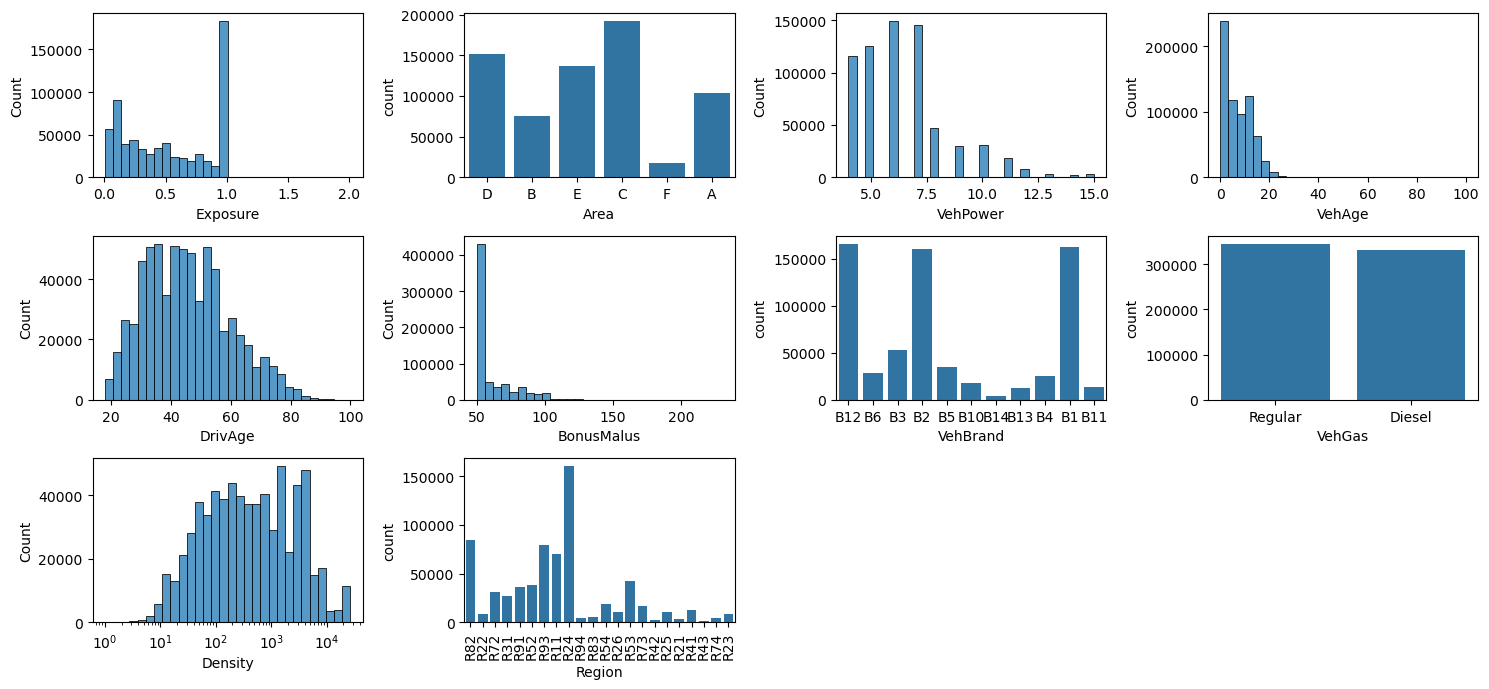

In [18]:
fig, axes = plt.subplots(3, 4, figsize=(15,7))
axes = axes.flatten()

features = list(df.columns.values)
del features[0:1]
del features[-1]

features_numerical = ["Exposure","VehPower","VehAge","DrivAge","BonusMalus","Density","ClaimRate"]
features_categorical = ["Area","VehBrand","VehGas","Region"]

print("Feature max:")


for feature, ax in zip(features,axes):
    if feature in features_numerical:
        if feature == "Density":
                sns.histplot(df[feature],bins=30,ax=ax,log_scale=True)
        else:
            sns.histplot(df[feature],bins=30,ax=ax)
    elif feature in features_categorical:
        sns.countplot(x=df[feature],ax=ax)

    if feature == "Region":
                plt.setp(ax.get_xticklabels(), rotation=90)
                

    
    grouped = df.groupby(feature).agg(
    ClaimNb=("ClaimNb", "sum"),
    Exposure=("Exposure", "sum")
)

    grouped["ClaimRate"] = grouped["ClaimNb"] / grouped["Exposure"]

    print(
    f"{feature}: {grouped['ClaimRate'].idxmax()} "
    f"({grouped['ClaimRate'].max():.3f} claims/yr)"
)

for ax in axes[len(features):]:
    ax.axis("off")

plt.tight_layout()
plt.show()



Findings from this
- Exposure heavily biased at 1.0 yrs, suggests that claims occur just before renewal? Disregarding this, skewed leftwards - claims happen soon after policy taken out.
- Area: F is low as expected, increases with density until C (max) then drops. Perhaps urban residents simply drive less? 
- VehPower: peaks at around '6'. Falls off with increase (expected - higher value cars would have more driver care)
- VehAge skews leftwards (obvious, as newer cars much more prevelent on road). Appears to be a spike at around 15yr - when cars tend to begin to deteriorate?
- DrivAge: peaks between 40 and 55, would expect left skew
- BonusMalus: Skewed left (Bonus), suggests the majorit of claims are made by people who never have (first-time claimer)
- VehBrand: unspecified, B12,B2,B1 take the lead substantially
- VehGas: approx equal - will be interesting to see if this follows the proportion of each fuel type present on the roads
- Density: See Area
- Region: Profound spike in R24 (val-de-loire)




### 05. Correlation
Producing a Correlation Matrix of the numerical datapoints reveal most features do NOT have a correlation with claim rate - this suggests linear relationships do not explain claim frequency.
- The highest correlation is between DrivAge and BonusMalus (-0.48) - this is fairly obvious, as an older driver has more time to accrue a lower BonusMalus than a younger driver, but suggests younger drivers have higher risk scores
- Exposure is not strongly correlated with any features, meaning policy length does not seem to depend on certain vehicle characteristics
- Vehical characteristics are also independent

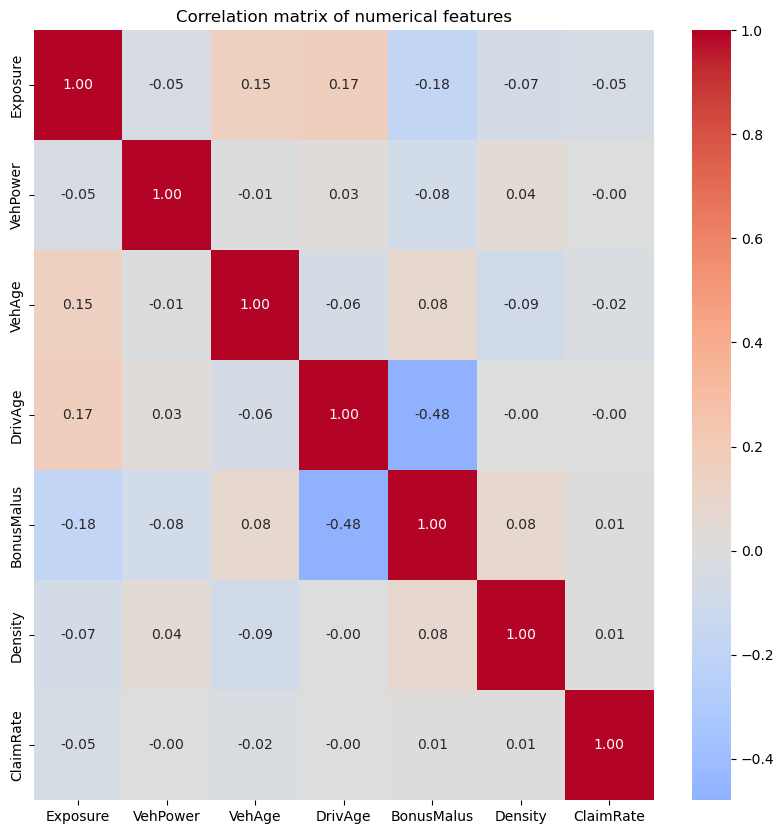

In [19]:
corr_matrix = df[features_numerical].corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr_matrix,annot=True,fmt=".2f",center=0,cmap="coolwarm")
plt.title("Correlation matrix of numerical features")
plt.show()



### 06: Claim Rate vs Features
The Pearson Correlation matrix was fairly unhelpful. To investigate NON-linear relations, it's worth doing plots of ClaimRate vs feature


C:\Users\oscar\AppData\Local\Temp\ipykernel_6856\3724088290.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  DrivAge_claim_rate = df.groupby("DrivAge_bins")["ClaimRate"].mean().reset_index()


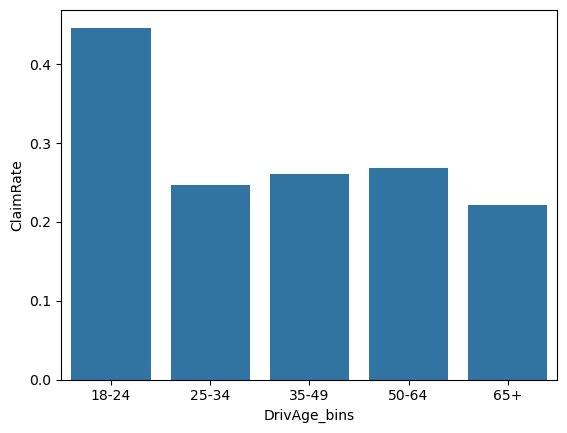

In [ ]:
    bins = [18,25,35,50,65,100]
    bin_labels = ["18-24","25-34","35-49","50-64","65+"]

    df["DrivAge_bins"] = pd.cut(
        df["DrivAge"],
        bins=bins,
        labels=bin_labels,
        right=False
    )

    
    DrivAge_claim_rate = df.groupby("DrivAge_bins")["ClaimRate"].mean().reset_index()

    sns.barplot(data=DrivAge_claim_rate, x="DrivAge_bins",y="ClaimRate")
    plt.show()


This shows that the 18-24 group do infact have more claims than older groups.
We can then do this with each feature.


C:\Users\oscar\AppData\Local\Temp\ipykernel_6856\1641895407.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.barplot(data=df.groupby(f"{feature}_bins")["ClaimRate"].mean().reset_index(),x=f"{feature}_bins",y="ClaimRate")
C:\Users\oscar\AppData\Local\Temp\ipykernel_6856\1641895407.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sns.barplot(data=df.groupby(f"{feature}_bins")["ClaimRate"].mean().reset_index(),x=f"{feature}_bins",y="ClaimRate")
C:\Users\oscar\AppData\Local\Temp\ipykernel_6856\1641895407.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a

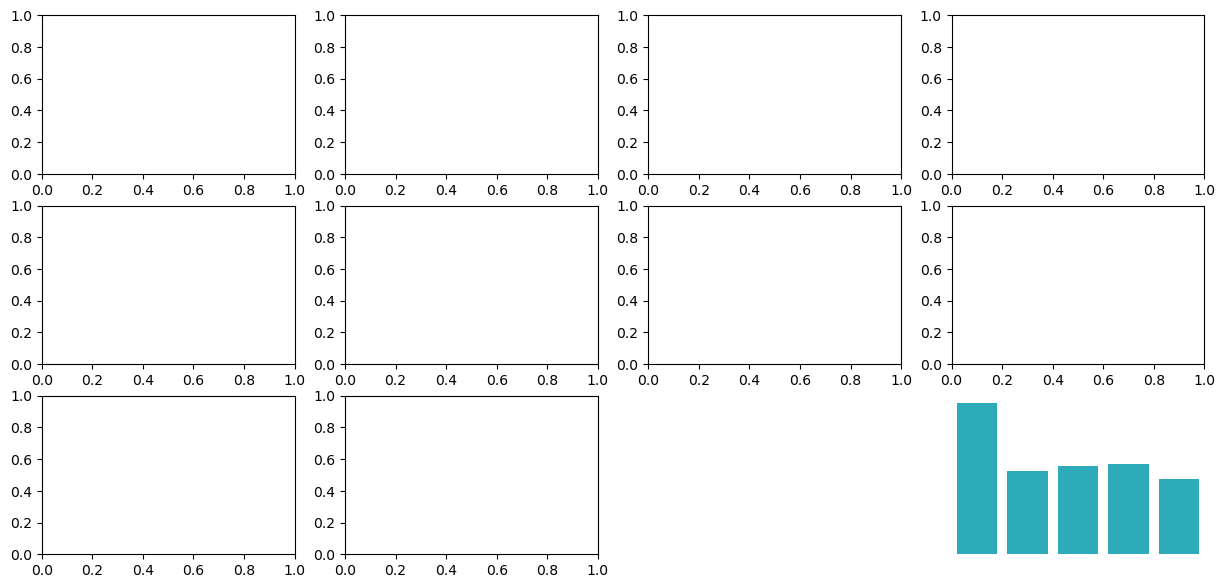

In [ ]:
fig, axes = plt.subplots(3, 4, figsize=(15,7))
axes = axes.flatten()

bin_dict = {
    "DrivAge": [18,25,35,50,65,100],
    "VehAge": [0,3,6,10,15,20,100],
    "BonusMalus": [50,75,100,125,150,200,250]
}
features_continuous = [f for f in features_numerical if f != "VehPower"]


for feature, ax in zip(features_continuous,axes):



    df[f"{feature}_bins"] = pd.cut(
        df[f"{feature}"],
        bins= bin_dict[feature]
        right=False
    )

    sns.barplot(data=df.groupby(f"{feature}_bins")["ClaimRate"].mean().reset_index(),x=f"{feature}_bins",y="ClaimRate",ax=ax)

for ax in axes[len(features):]:
    ax.axis("off")
plt.show()